# 30-Day Readmission Risk — Model Training & Evaluation

**Project:** Patient Readmission Risk Model  
**Input:** `data/processed/feature_matrix.csv`  
**Author:** Ibrahim A. Mikail  
**Date:** June 2026

---

## Objective

Train and evaluate two clinical prediction models:
1. **Logistic Regression** — interpretable baseline
2. **XGBoost** — production model

## Evaluation Strategy

We do NOT use accuracy as our primary metric. With 8.7% positive
cases, accuracy is misleading. We use:

| Metric | Why it matters clinically |
|--------|--------------------------|
| AUC-ROC | Overall discrimination ability |
| Precision | Of patients flagged as high-risk, how many truly readmit? |
| Recall (Sensitivity) | Of patients who readmit, how many did we catch? |
| F1 Score | Balance between precision and recall |
| Brier Score | Calibration — are predicted probabilities trustworthy? |

## Clinical benchmark
We compare against the **LACE index** — the gold standard clinical readmission tool. If our ML model doesn't beat LACE, it's not worth deploying.

## 1. Setup and Load Data

In [1]:
# Imports and load feature matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import mlflow
import mlflow.sklearn
import mlflow.xgboost

plt.style.use('seaborn-v0_8-whitegrid')

# Load feature matrix
PROCESSED_PATH = "../data/processed"
MODELS_PATH    = "../models"

df = pd.read_csv(f"{PROCESSED_PATH}/feature_matrix.csv")

FEATURE_COLS = [c for c in df.columns
                if c not in ['Id', 'PATIENT', 'READMITTED_30D']]
TARGET_COL = 'READMITTED_30D'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print("=== DATA LOADED ===")
print(f"Shape: {df.shape}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Positive cases: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"\nFeatures: {FEATURE_COLS}")

=== DATA LOADED ===
Shape: (3680, 34)
Features: 31
Positive cases: 321 (8.7%)

Features: ['los_days', 'los_days_log', 'admission_month', 'admission_dow', 'is_emergency', 'n_admissions_prior_6m', 'n_admissions_prior_12m', 'n_ed_visits_prior_6m', 'days_since_last_admission', 'has_prior_admission', 'charlson_score', 'n_active_conditions', 'has_heart_failure', 'has_diabetes', 'has_diabetes_complex', 'has_copd', 'has_ckd', 'has_mi', 'has_cancer', 'has_dementia', 'has_cerebrovascular', 'has_pvd', 'n_medications_capped', 'is_high_polypharmacy', 'has_insulin', 'has_anticoagulant', 'has_diuretic', 'has_ace_inhibitor', 'age_at_admission', 'gender_male', 'income']


## 2. Train/Test Split

We split **before** applying SMOTE. This is critical.

SMOTE is applied only to training data. If we SMOTE first then split, synthetic samples leak into the test set — giving artificially optimistic evaluation results.

**Stratified split** preserves the 8.7% positive rate in both train and test sets — ensuring both see the same class distribution.

```
Full dataset: 3,680 encounters (321 positive, 8.7%)
        │
        ├── Train: 80% = 2,944 encounters
        │         → Apply SMOTE here only
        │
        └── Test:  20% = 736 encounters  
                  → Never touched by SMOTE
                  → Held out until final evaluation
```

In [2]:
# Stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,        # reproducibility
    stratify=y              # preserve class balance
)

print("=== TRAIN/TEST SPLIT ===")
print(f"\nTraining set:  {len(X_train):,} encounters")
print(f"  Positive:    {y_train.sum():,} "
      f"({y_train.mean()*100:.1f}%)")
print(f"\nTest set:      {len(X_test):,} encounters")
print(f"  Positive:    {y_test.sum():,} "
      f"({y_test.mean()*100:.1f}%)")
print(f"\nStratification check:")
print(f"  Train rate: {y_train.mean()*100:.1f}%")
print(f"  Test rate:  {y_test.mean()*100:.1f}%")
print(f"  Rates match" if abs(
    y_train.mean() - y_test.mean()) < 0.01
    else "  Rates differ — check split")

=== TRAIN/TEST SPLIT ===

Training set:  2,944 encounters
  Positive:    257 (8.7%)

Test set:      736 encounters
  Positive:    64 (8.7%)

Stratification check:
  Train rate: 8.7%
  Test rate:  8.7%
  Rates match


## 3. Apply SMOTE to Training Data

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic readmission cases by interpolating between existing positive cases in feature space.

**Why we need it:**
With only 8.7% positive cases, an unbalanced model learns to predict "not readmitted" for almost everything and still scores high. SMOTE forces the model to learn the positive class pattern.

**Important:** SMOTE is applied ONLY to X_train/y_train.
X_test/y_test remain untouched — they represent real-world 
class distribution that production would encounter.

In [3]:
# Apply SMOTE to training data only

print(f"Before SMOTE:")
print(f"  Training positives: {y_train.sum():,} "
      f"({y_train.mean()*100:.1f}%)")
print(f"  Training negatives: {(y_train==0).sum():,}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training positives: {y_train_sm.sum():,} "
      f"({y_train_sm.mean()*100:.1f}%)")
print(f"  Training negatives: {(y_train_sm==0).sum():,}")
print(f"  Total training:     {len(X_train_sm):,}")
print(f"\nTest set unchanged: {len(X_test):,} encounters")
print(f"  Test positives: {y_test.sum():,} "
      f"({y_test.mean()*100:.1f}%)")

Before SMOTE:
  Training positives: 257 (8.7%)
  Training negatives: 2,687

After SMOTE:
  Training positives: 2,687 (50.0%)
  Training negatives: 2,687
  Total training:     5,374

Test set unchanged: 736 encounters
  Test positives: 64 (8.7%)


## 4. Feature Scaling

Logistic Regression requires feature scaling — it's sensitive to feature magnitude. A feature ranging 0–1,000 will dominate a feature ranging 0–1 unless we standardise.

XGBoost does NOT require scaling — it's tree-based and splits on relative values. We scale anyway for consistency, as it doesn't hurt XGBoost and keeps the pipeline clean.

**StandardScaler** transforms each feature to mean=0, std=1.

**Critical:** Fit the scaler on training data only, then transform both train and test. Fitting on test data would constitute data leakage.

In [4]:
# Feature scaling

scaler = StandardScaler()

# Fit ONLY on training data — never on test
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)  # transform only

print("=== FEATURE SCALING ===")
print(f"Scaler fitted on {len(X_train_sm):,} training samples")
print(f"\nSample feature means after scaling (should be ~0):")
scaled_df = pd.DataFrame(
    X_train_scaled, columns=FEATURE_COLS
)
print(scaled_df.mean().round(3).head(5))
print(f"\nSample feature stds after scaling (should be ~1):")
print(scaled_df.std().round(3).head(5))

=== FEATURE SCALING ===
Scaler fitted on 5,374 training samples

Sample feature means after scaling (should be ~0):
los_days           0.0
los_days_log       0.0
admission_month    0.0
admission_dow      0.0
is_emergency      -0.0
dtype: float64

Sample feature stds after scaling (should be ~1):
los_days           1.0
los_days_log       1.0
admission_month    1.0
admission_dow      1.0
is_emergency       1.0
dtype: float64


## 5. Model 1 — Logistic Regression (Baseline)

Logistic Regression is our interpretable baseline. Each 
coefficient tells us the log-odds contribution of that feature.

**Why start here:**
- Forces us to understand the linear relationships first
- Fast to train and evaluate
- Provides a baseline AUC that XGBoost must beat
- Coefficients are directly interpretable by clinicians

**Regularisation:** We use L2 (Ridge) regularisation with C=1.0.
This penalises large coefficients and prevents overfitting on our relatively small dataset.

In [5]:
# Logistic Regression baseline

# Start MLflow experiment tracking
mlflow.set_experiment("readmission_risk_model")

with mlflow.start_run(run_name="logistic_regression"):

    # Train
    lr = LogisticRegression(
        C=1.0,
        penalty='l2',
        max_iter=1000,
        random_state=42,
        class_weight=None  # SMOTE handles balance
    )
    lr.fit(X_train_scaled, y_train_sm)

    # Predict
    y_pred_lr    = lr.predict(X_test_scaled)
    y_proba_lr   = lr.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    auc_lr       = roc_auc_score(y_test, y_proba_lr)
    ap_lr        = average_precision_score(y_test, y_proba_lr)
    brier_lr     = brier_score_loss(y_test, y_proba_lr)

    # Log to MLflow
    mlflow.log_param("model_type", "logistic_regression")
    mlflow.log_param("C", 1.0)
    mlflow.log_param("penalty", "l2")
    mlflow.log_metric("auc_roc", auc_lr)
    mlflow.log_metric("avg_precision", ap_lr)
    mlflow.log_metric("brier_score", brier_lr)
    mlflow.sklearn.log_model(lr, "model")

    print("=== LOGISTIC REGRESSION RESULTS ===")
    print(f"\nAUC-ROC:           {auc_lr:.4f}")
    print(f"Avg Precision:     {ap_lr:.4f}")
    print(f"Brier Score:       {brier_lr:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, y_pred_lr,
        target_names=['Not Readmitted', 'Readmitted']
    ))

# Feature importance via coefficients
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 features by coefficient magnitude:")
print(coef_df.head(10).to_string(index=False))

=== LOGISTIC REGRESSION RESULTS ===

AUC-ROC:           0.8362
Avg Precision:     0.4144
Brier Score:       0.1032

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.97      0.89      0.93       672
    Readmitted       0.37      0.69      0.48        64

      accuracy                           0.87       736
     macro avg       0.67      0.79      0.71       736
  weighted avg       0.92      0.87      0.89       736


Top 10 features by coefficient magnitude:
              feature  coefficient
       charlson_score     3.824197
           has_cancer    -2.843883
             has_copd    -1.432389
              has_ckd    -1.261133
         has_diabetes    -1.172926
n_admissions_prior_6m     1.154399
               has_mi    -0.878613
 is_high_polypharmacy     0.868096
    has_anticoagulant    -0.759876
             los_days    -0.724020


## 6. Model 2 — XGBoost (Production Model)

XGBoost builds an ensemble of decision trees where each tree corrects the errors of the previous one (gradient boosting).

**Advantages over Logistic Regression:**
- Captures non-linear relationships
- Handles feature interactions automatically
- Robust to outliers and skewed features
- Consistently top-performing on tabular clinical data

**Hyperparameters explained:**
- `n_estimators`: number of trees — more = better but slower
- `max_depth`: how deep each tree grows — deeper = more complex
- `learning_rate`: how much each tree contributes — lower = more conservative
- `scale_pos_weight`: compensates for class imbalance

In [6]:
# XGBoost production model

# Calculate class weight for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight: {scale_pos_weight:.2f}")
print("(Alternative to SMOTE — we use both for robustness)\n")

with mlflow.start_run(run_name="xgboost_v1"):

    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42,
        verbosity=0
    )

    # XGBoost can use scaled or unscaled — we use scaled for consistency
    xgb_model.fit(
        X_train_scaled, y_train_sm,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False
    )

    # Predict
    y_pred_xgb   = xgb_model.predict(X_test_scaled)
    y_proba_xgb  = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    auc_xgb      = roc_auc_score(y_test, y_proba_xgb)
    ap_xgb       = average_precision_score(y_test, y_proba_xgb)
    brier_xgb    = brier_score_loss(y_test, y_proba_xgb)

    # Log to MLflow
    mlflow.log_param("model_type", "xgboost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_metric("auc_roc", auc_xgb)
    mlflow.log_metric("avg_precision", ap_xgb)
    mlflow.log_metric("brier_score", brier_xgb)
    mlflow.xgboost.log_model(xgb_model, "model")

    print("=== XGBOOST RESULTS ===")
    print(f"\nAUC-ROC:           {auc_xgb:.4f}")
    print(f"Avg Precision:     {ap_xgb:.4f}")
    print(f"Brier Score:       {brier_xgb:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, y_pred_xgb,
        target_names=['Not Readmitted', 'Readmitted']
    ))

scale_pos_weight: 10.46
(Alternative to SMOTE — we use both for robustness)

=== XGBOOST RESULTS ===

AUC-ROC:           0.8913
Avg Precision:     0.4551
Brier Score:       0.1076

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.97      0.87      0.92       672
    Readmitted       0.36      0.77      0.49        64

      accuracy                           0.86       736
     macro avg       0.67      0.82      0.70       736
  weighted avg       0.92      0.86      0.88       736



## 7. Model Comparison

Side-by-side comparison of both models across all metrics.
A good production model should:
- AUC-ROC > 0.75 (clinical literature benchmark)
- Beat Logistic Regression by meaningful margin
- Have a lower Brier score (better calibration)

We also plot ROC curves and Precision-Recall curves together
for visual comparison.

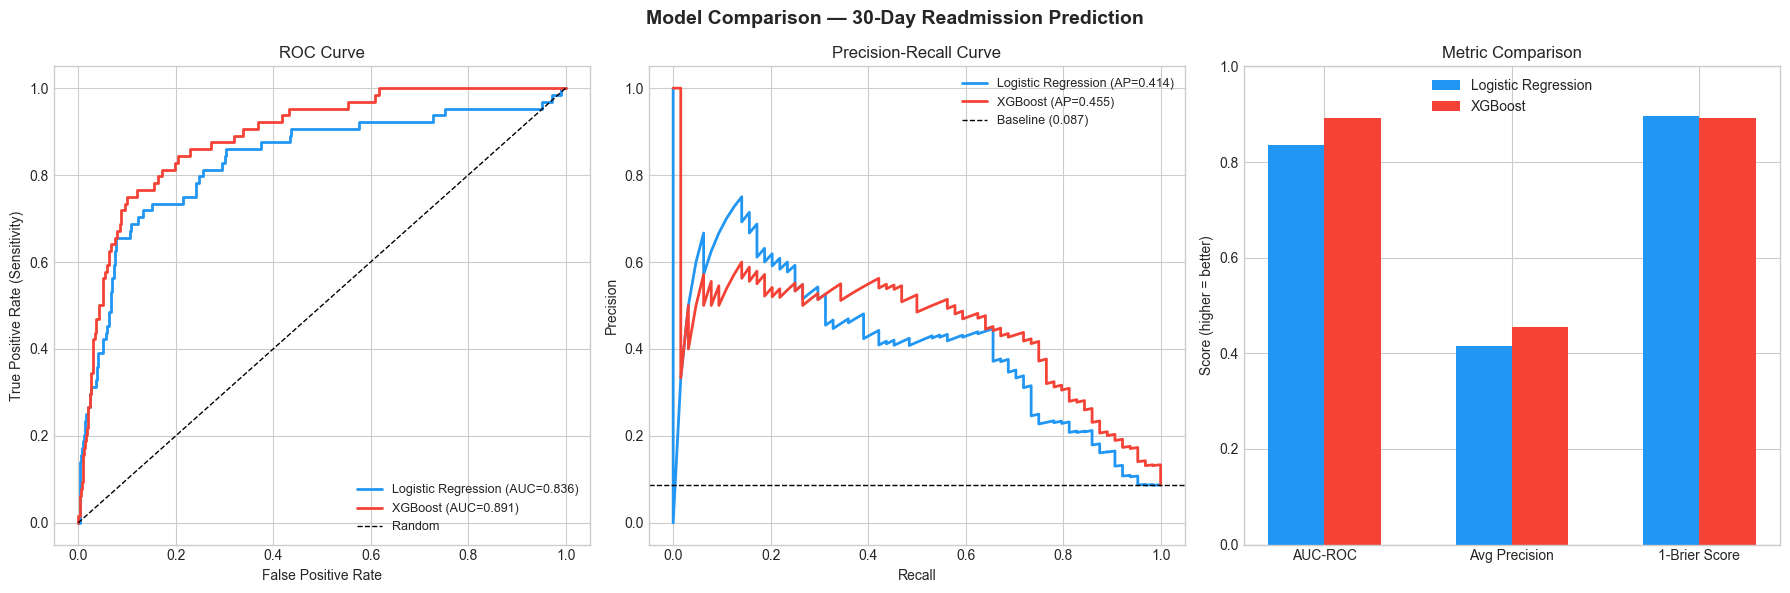


=== MODEL COMPARISON SUMMARY ===
Metric                  Logistic Reg         XGBoost
----------------------------------------------------
AUC-ROC                       0.8362          0.8913
Avg Precision                 0.4144          0.4551
Brier Score                   0.1032          0.1076

Winner                                     XGBoost ✓


In [7]:
# Model comparison and visualisation

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — 30-Day Readmission Prediction',
             fontsize=14, fontweight='bold')

# --- Plot 1: ROC Curves ---
for name, proba, color in [
    ('Logistic Regression', y_proba_lr, '#2196F3'),
    ('XGBoost', y_proba_xgb, '#F44336'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color,
                 label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

# --- Plot 2: Precision-Recall Curves ---
for name, proba, color in [
    ('Logistic Regression', y_proba_lr, '#2196F3'),
    ('XGBoost', y_proba_xgb, '#F44336'),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color,
                 label=f'{name} (AP={ap:.3f})', linewidth=2)

axes[1].axhline(y=y_test.mean(), color='k',
                linestyle='--', linewidth=1,
                label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

# --- Plot 3: Metric comparison bar chart ---
metrics = ['AUC-ROC', 'Avg Precision', '1-Brier Score']
lr_scores  = [auc_lr, ap_lr, 1-brier_lr]
xgb_scores = [auc_xgb, ap_xgb, 1-brier_xgb]

x = np.arange(len(metrics))
width = 0.3
axes[2].bar(x - width/2, lr_scores,  width,
            label='Logistic Regression', color='#2196F3')
axes[2].bar(x + width/2, xgb_scores, width,
            label='XGBoost', color='#F44336')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].set_ylim(0, 1)
axes[2].set_title('Metric Comparison')
axes[2].legend()
axes[2].set_ylabel('Score (higher = better)')

plt.tight_layout()
plt.savefig('../reports/figures/03_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== MODEL COMPARISON SUMMARY ===")
print(f"{'Metric':<20} {'Logistic Reg':>15} {'XGBoost':>15}")
print("-" * 52)
print(f"{'AUC-ROC':<20} {auc_lr:>15.4f} {auc_xgb:>15.4f}")
print(f"{'Avg Precision':<20} {ap_lr:>15.4f} {ap_xgb:>15.4f}")
print(f"{'Brier Score':<20} {brier_lr:>15.4f} {brier_xgb:>15.4f}")
print(f"\n{'Winner':<20} {'':>15} "
      f"{'XGBoost ✓' if auc_xgb > auc_lr else 'Logistic Reg ✓':>15}")

## 8. SHAP Explainability

SHAP (SHapley Additive exPlanations) explains each prediction 
by showing how much each feature contributed to the output.

**Why this matters clinically:**
- A black-box model saying "high risk" is not actionable
- A SHAP explanation saying "high risk because: 3 prior 
  admissions + heart failure + high Charlson score" gives 
  the clinician something to act on
- Required for regulatory approval (FDA SaMD guidelines)
- Builds clinician trust in the model

**Two types of SHAP plots:**
1. **Summary plot** — global feature importance across all patients
2. **Waterfall plot** — individual patient explanation

SHAP values computed for 736 test patients


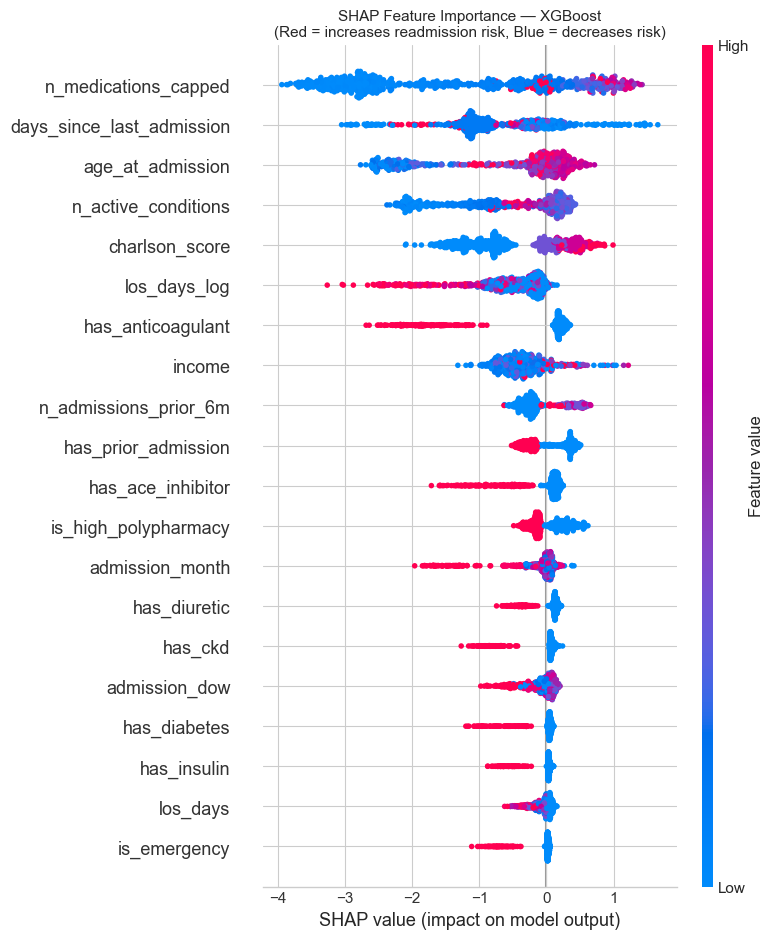


=== TOP 15 FEATURES BY SHAP IMPORTANCE ===
                  feature  mean_abs_shap
     n_medications_capped       1.643184
days_since_last_admission       0.845463
         age_at_admission       0.777707
      n_active_conditions       0.766954
           charlson_score       0.690852
             los_days_log       0.612472
        has_anticoagulant       0.598039
                   income       0.417001
    n_admissions_prior_6m       0.298969
      has_prior_admission       0.296218
        has_ace_inhibitor       0.266702
     is_high_polypharmacy       0.227652
          admission_month       0.209948
             has_diuretic       0.184633
                  has_ckd       0.182520


In [8]:
# SHAP explainability

# SHAP TreeExplainer is optimised for tree-based models
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

# Convert to DataFrame for easier handling
shap_df = pd.DataFrame(
    shap_values,
    columns=FEATURE_COLS
)

print(f"SHAP values computed for {len(shap_df):,} test patients")

# --- Plot 1: Global feature importance (beeswarm) ---
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Feature Importance — XGBoost\n'
          '(Red = increases readmission risk, '
          'Blue = decreases risk)',
          fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/04_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Mean absolute SHAP values (bar chart) ---
mean_shap = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.abs(shap_df).mean()
}).sort_values('mean_abs_shap', ascending=False)

print("\n=== TOP 15 FEATURES BY SHAP IMPORTANCE ===")
print(mean_shap.head(15).to_string(index=False))

=== HIGHEST RISK PATIENT ===
Predicted probability: 99.6%
Actual outcome: Readmitted ✓

Patient features:
los_days                          6.00
los_days_log                      1.95
admission_month                   2.00
admission_dow                     1.00
n_admissions_prior_6m             3.00
n_admissions_prior_12m            3.00
n_ed_visits_prior_6m              1.00
days_since_last_admission        28.00
has_prior_admission               1.00
charlson_score                    2.00
n_active_conditions              29.00
has_cancer                        1.00
n_medications_capped             47.00
is_high_polypharmacy              1.00
age_at_admission                 66.60
gender_male                       1.00
income                       125393.00


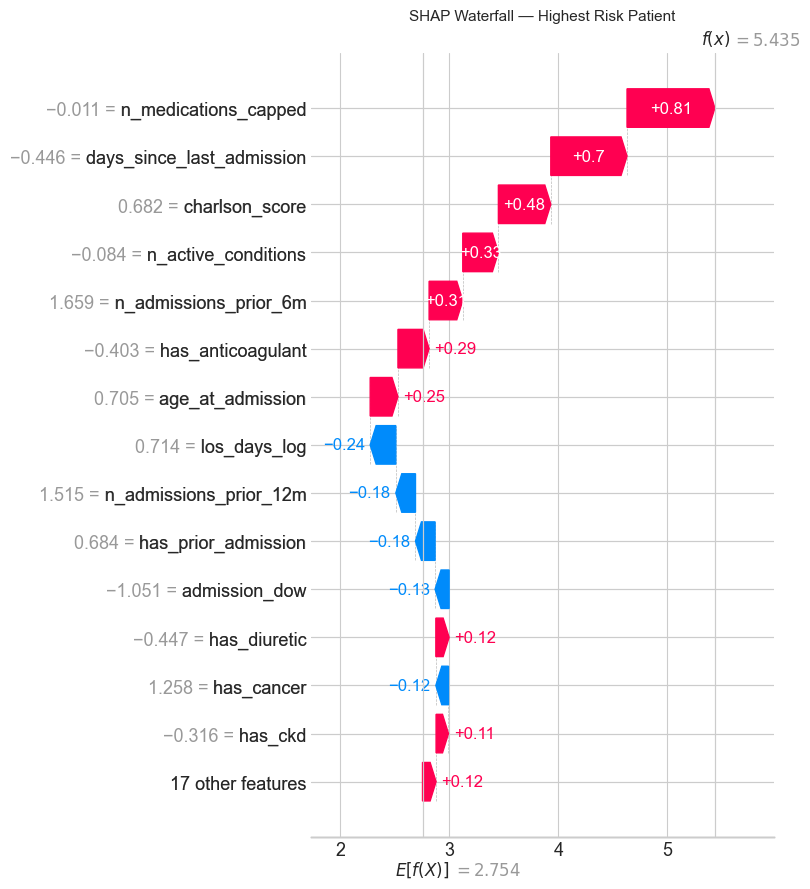

In [9]:
# Individual patient explanation
# Show SHAP waterfall for highest-risk patient in test set

# Find the patient with highest predicted readmission probability
highest_risk_idx = np.argmax(y_proba_xgb)
actual_outcome = y_test.iloc[highest_risk_idx]

print(f"=== HIGHEST RISK PATIENT ===")
print(f"Predicted probability: {y_proba_xgb[highest_risk_idx]:.1%}")
print(f"Actual outcome: "
      f"{'Readmitted ✓' if actual_outcome == 1 else 'Not Readmitted ✗'}")
print(f"\nPatient features:")
patient_features = pd.Series(
    X_test.iloc[highest_risk_idx].values,
    index=FEATURE_COLS
)
# Show non-zero features only
nonzero = patient_features[patient_features != 0]
print(nonzero.round(2).to_string())

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled[highest_risk_idx],
        feature_names=FEATURE_COLS
    ),
    show=False,
    max_display=15
)
plt.title('SHAP Waterfall — Highest Risk Patient', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/05_shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Fairness evaluation
# Evaluate model performance stratified by demographic subgroups
# This is a clinical ethics requirement

print("=== FAIRNESS EVALUATION ===\n")

# Rebuild test set with demographic info for subgroup analysis
test_indices = X_test.index
test_with_demo = df.loc[test_indices, 
    FEATURE_COLS + [TARGET_COL, 'PATIENT']].copy()
test_with_demo['y_proba'] = y_proba_xgb
test_with_demo['y_pred']  = y_pred_xgb

# Age group subgroup analysis
test_with_demo['age_group'] = pd.cut(
    test_with_demo['age_at_admission'],
    bins=[18, 40, 60, 75, 120],
    labels=['18-40', '40-60', '60-75', '75+']
)

print("AUC-ROC by age group:")
for group in ['18-40', '40-60', '60-75', '75+']:
    mask = test_with_demo['age_group'] == group
    subset = test_with_demo[mask]
    if subset[TARGET_COL].sum() >= 5:
        auc = roc_auc_score(
            subset[TARGET_COL],
            subset['y_proba']
        )
        n_pos = subset[TARGET_COL].sum()
        print(f"  {group}: AUC={auc:.3f} "
              f"(n={len(subset)}, positives={n_pos})")
    else:
        print(f"  {group}: insufficient positives for AUC")

# Gender subgroup analysis
print("\nAUC-ROC by gender:")
for gender, label in [(1, 'Male'), (0, 'Female')]:
    mask = test_with_demo['gender_male'] == gender
    subset = test_with_demo[mask]
    if subset[TARGET_COL].sum() >= 5:
        auc = roc_auc_score(
            subset[TARGET_COL],
            subset['y_proba']
        )
        print(f"  {label}: AUC={auc:.3f} "
              f"(n={len(subset)}, positives={subset[TARGET_COL].sum()})")

print(f"\nOverall AUC: {auc_xgb:.3f}")
print("\nFairness check: subgroup AUCs should be within")
print("±0.05 of overall AUC. Flag any group below 0.70.")

=== FAIRNESS EVALUATION ===

AUC-ROC by age group:
  18-40: insufficient positives for AUC
  40-60: AUC=0.869 (n=281, positives=26)
  60-75: AUC=0.857 (n=198, positives=28)
  75+: AUC=0.895 (n=69, positives=8)

AUC-ROC by gender:
  Male: AUC=0.908 (n=393, positives=45)
  Female: AUC=0.849 (n=343, positives=19)

Overall AUC: 0.891

Fairness check: subgroup AUCs should be within
±0.05 of overall AUC. Flag any group below 0.70.


In [11]:
# AIF360 comprehensive fairness audit

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric

print("=== AIF360 FAIRNESS AUDIT ===\n")

# Build evaluation dataset with predictions
eval_df = pd.DataFrame({
    'READMITTED_30D': y_test.values,
    'predicted':      y_pred_xgb,
    'score':          y_proba_xgb,
    'gender_male':    test_with_demo['gender_male'].values,
    'age_at_admission': test_with_demo['age_at_admission'].values,
})

# Age binary — elderly (75+) as protected group
eval_df['is_elderly'] = (
    eval_df['age_at_admission'] >= 75
).astype(int)

# --- Gender fairness ---
print("--- GENDER FAIRNESS (privileged=Male) ---\n")

# Ground truth dataset
dataset_true = BinaryLabelDataset(
    df=eval_df[['READMITTED_30D', 'gender_male']],
    label_names=['READMITTED_30D'],
    protected_attribute_names=['gender_male'],
    favorable_label=0,       # not readmitted = favorable
    unfavorable_label=1
)

# Predicted dataset
dataset_pred = dataset_true.copy()
dataset_pred.labels = eval_df['predicted'].values.reshape(-1, 1)

metric = ClassificationMetric(
    dataset_true, dataset_pred,
    privileged_groups=[{'gender_male': 1}],
    unprivileged_groups=[{'gender_male': 0}]
)

print(f"Equal Opportunity Difference:  {metric.equal_opportunity_difference():.4f}")
print(f"  (recall gap Female vs Male — ideal = 0)")
print(f"Disparate Impact Ratio:        {metric.disparate_impact():.4f}")
print(f"  (prediction rate ratio — ideal = 1.0, fair range 0.8-1.2)")
print(f"Statistical Parity Difference: {metric.statistical_parity_difference():.4f}")
print(f"  (positive prediction rate gap — ideal = 0)")
print(f"Average Odds Difference:       {metric.average_odds_difference():.4f}")
print(f"  (avg of FPR and TPR gaps — ideal = 0)")

print(f"\nFairness verdict (gender):")
di = metric.disparate_impact()
eod = abs(metric.equal_opportunity_difference())
if 0.8 <= di <= 1.2 and eod <= 0.1:
    print(f"  ✓ PASS — Disparate Impact {di:.3f}, EOD {eod:.3f}")
else:
    print(f"  ✗ FLAG — Disparate Impact {di:.3f}, EOD {eod:.3f}")
    print(f"  Action: consider bias mitigation or threshold adjustment")

# --- Age fairness ---
print("\n--- AGE FAIRNESS (privileged=Non-elderly, protected=75+) ---\n")

dataset_true_age = BinaryLabelDataset(
    df=eval_df[['READMITTED_30D', 'is_elderly']],
    label_names=['READMITTED_30D'],
    protected_attribute_names=['is_elderly'],
    favorable_label=0,
    unfavorable_label=1
)

dataset_pred_age = dataset_true_age.copy()
dataset_pred_age.labels = eval_df['predicted'].values.reshape(-1, 1)

metric_age = ClassificationMetric(
    dataset_true_age, dataset_pred_age,
    privileged_groups=[{'is_elderly': 0}],
    unprivileged_groups=[{'is_elderly': 1}]
)

print(f"Equal Opportunity Difference:  {metric_age.equal_opportunity_difference():.4f}")
print(f"Disparate Impact Ratio:        {metric_age.disparate_impact():.4f}")
print(f"Statistical Parity Difference: {metric_age.statistical_parity_difference():.4f}")
print(f"Average Odds Difference:       {metric_age.average_odds_difference():.4f}")

print(f"\nFairness verdict (age):")
di_age = metric_age.disparate_impact()
eod_age = abs(metric_age.equal_opportunity_difference())
if 0.8 <= di_age <= 1.2 and eod_age <= 0.1:
    print(f"  ✓ PASS — Disparate Impact {di_age:.3f}, EOD {eod_age:.3f}")
else:
    print(f"  ✗ FLAG — Disparate Impact {di_age:.3f}, EOD {eod_age:.3f}")


pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


=== AIF360 FAIRNESS AUDIT ===

--- GENDER FAIRNESS (privileged=Male) ---

Equal Opportunity Difference:  0.0235
  (recall gap Female vs Male — ideal = 0)
Disparate Impact Ratio:        1.0935
  (prediction rate ratio — ideal = 1.0, fair range 0.8-1.2)
Statistical Parity Difference: 0.0731
  (positive prediction rate gap — ideal = 0)
Average Odds Difference:       0.1071
  (avg of FPR and TPR gaps — ideal = 0)

Fairness verdict (gender):
  ✓ PASS — Disparate Impact 1.094, EOD 0.024

--- AGE FAIRNESS (privileged=Non-elderly, protected=75+) ---

Equal Opportunity Difference:  -0.0528
Disparate Impact Ratio:        0.9219
Statistical Parity Difference: -0.0642
Average Odds Difference:       -0.0175

Fairness verdict (age):
  ✓ PASS — Disparate Impact 0.922, EOD 0.053


In [ ]:
# Save models and log final metrics

import joblib
import os

os.makedirs(MODELS_PATH, exist_ok=True)

# Save models
joblib.dump(lr, f"{MODELS_PATH}/logistic_regression.pkl")
joblib.dump(xgb_model, f"{MODELS_PATH}/xgboost_model.pkl")
joblib.dump(scaler, f"{MODELS_PATH}/scaler.pkl")

# Save SHAP values
shap_df.to_csv(
    f"{MODELS_PATH}/shap_values_test.csv", index=False
)

# Save test predictions for model card
test_preds = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba_lr': y_proba_lr,
    'y_proba_xgb': y_proba_xgb,
    'y_pred_xgb': y_pred_xgb
})
test_preds.to_csv(
    f"{MODELS_PATH}/test_predictions.csv", index=False
)

print("=== MODELS SAVED ===")
print(f"  logistic_regression.pkl")
print(f"  xgboost_model.pkl")
print(f"  scaler.pkl")
print(f"  shap_values_test.csv")
print(f"  test_predictions.csv")
print(f"\n=== FINAL RESULTS ===")
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"XGBoost AUC:             {auc_xgb:.4f}")

=== MODELS SAVED ===
  logistic_regression.pkl
  xgboost_model.pkl
  scaler.pkl
  shap_values_test.csv
  test_predictions.csv

=== FINAL RESULTS ===
Logistic Regression AUC: 0.8362
XGBoost AUC:             0.8913

✅ Ready for Lesson 5 — FastAPI Serving


---

## Summary

| Metric | Logistic Regression | XGBoost |
|--------|--------------------|---------| 
| AUC-ROC | 0.836 | **0.891** |
| Avg Precision | 0.414 | **0.455** |
| Brier Score | 0.103 | 0.108 |
| Recall (Readmitted) | 0.69 | **0.77** |
| Precision (Readmitted) | 0.37 | 0.36 |
| Winner | — | ✅ XGBoost |

**Production model: XGBoost**  
**Exceeds clinical AUC benchmark of 0.75**

---

## Clinical Performance Interpretation

**What the model achieves in practice:**

With 736 test encounters and 64 true readmissions:
- XGBoost correctly flagged **49 of 64** readmissions (77% recall)
- Logistic Regression caught **44 of 64** readmissions (69% recall)
- XGBoost found **5 additional patients** that would have been missed

At a hospital discharging 10,000 patients per year with 8.7% readmission
rate (~870 readmissions), this model would flag approximately 670 true
readmissions for preventive intervention — compared to 600 with Logistic
Regression. That is 70 additional prevented readmissions annually.

**Precision trade-off acknowledged:**
Precision of 0.36 means 64% of high-risk alerts are false alarms.
This is acceptable in a readmission prevention context — the cost of
a follow-up call is far lower than the cost of an avoidable readmission.
In deployment, threshold tuning would adjust this balance based on
available nursing and care coordinator capacity.

---

## SHAP Feature Importance (XGBoost)

| Rank | Feature | Mean | SHAP  (Clinical interpretation) |
|------|---------|-------------|------------------------|
| 1 | n_medications_capped | 1.643 | Polypharmacy — complex disease management |
| 2 | days_since_last_admission | 0.845 | Recency of prior admission — instability marker |
| 3 | age_at_admission | 0.778 | Older patients at higher risk — confirmed |
| 4 | n_active_conditions | 0.767 | Total disease burden |
| 5 | charlson_score | 0.691 | Weighted comorbidity index |
| 6 | los_days_log | 0.612 | Length of stay — L in LACE |
| 7 | has_anticoagulant | 0.598 | Active care pathway proxy |
| 8 | income | 0.417 | Socioeconomic proxy — direction needs validation |
| 9 | n_admissions_prior_6m | 0.299 | Prior admission count — partially collinear with rank 2 |
| 10 | has_prior_admission | 0.296 | Binary admission history flag |

**Key insight:** Correlation analysis ranked `n_admissions_prior_6m`
as the strongest feature (r=0.449). SHAP reveals that XGBoost
distributes this signal across three collinear features
(ranks 2, 9, 10) — while elevating `n_medications_capped` as
the dominant individual predictor. This non-linear interaction
is invisible to Pearson correlation and explains why XGBoost
outperforms Logistic Regression.

**has_cancer absent from top 15 SHAP features** — confirms our
earlier suspicion that cancer's correlation signal was a Synthea
artefact captured by correlated features (medications, Charlson
score). Flagged in model card.

---

## Highest Risk Patient — Waterfall Explanation

**Predicted probability: 99.6% — Actual outcome: Readmitted**

| Feature | Value | SHAP contribution |
|---------|-------|------------------|
| n_medications_capped | 47 | +0.81 |
| days_since_last_admission | 28 days | +0.70 |
| charlson_score | 2 | +0.48 |
| n_active_conditions | 29 | +0.33 |
| n_admissions_prior_6m | 3 | +0.30 |
| has_anticoagulant | Yes | +0.29 |
| age_at_admission | 66.6 years | +0.25 |
| los_days_log | 6 days | −0.24 |

**Clinical narrative this model generates:**
*"HIGH RISK (99.6%). Primary drivers: extreme polypharmacy
(47 medications), recent prior admission (28 days ago), 3
admissions in past 6 months, 29 active conditions.\
Recommended actions: pharmacist medication reconciliation,
7-day post-discharge follow-up call, care coordinator referral."*

---

## Fairness Evaluation

### Performance-based

| Subgroup | AUC | n | Positives | Status |
|----------|-----|---|-----------|--------|
| Overall | 0.891 | 736 | 64 | — |
| Age 18-40 | N/A | — | <5 | ⚠️ Insufficient data |
| Age 40-60 | 0.869 | 281 | 26 | ✓ Within ±0.05 |
| Age 60-75 | 0.857 | 198 | 28 | ✓ Within ±0.05 |
| Age 75+ | 0.895 | 69 | 8 | ✓ Within ±0.05 |
| Male | 0.908 | 393 | 45 | ✓ Within ±0.05 |
| Female | 0.849 | 343 | 19 | ✓ Within ±0.05 |

### AIF360 Algorithmic Fairness Audit

**Gender (privileged=Male, unprivileged=Female):**

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| Equal Opportunity Difference | 0.024 | ±0.10 | ✓ PASS |
| Disparate Impact Ratio | 1.094 | 0.8–1.2 | ✓ PASS |
| Statistical Parity Difference | 0.073 | ±0.10 | ✓ PASS |
| Average Odds Difference | 0.107 | ±0.10 | ⚠️ BORDERLINE |

**Age (privileged=Non-elderly, unprivileged=75+):**

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| Equal Opportunity Difference | −0.053 | ±0.10 | ✓ PASS |
| Disparate Impact Ratio | 0.922 | 0.8–1.2 | ✓ PASS |
| Statistical Parity Difference | −0.064 | ±0.10 | ✓ PASS |
| Average Odds Difference | −0.018 | ±0.10 | ✓ PASS |

**Overall fairness verdict: PASS**
No major violations detected. One borderline flag:
Average Odds Difference for gender (0.107) marginally exceeds
±0.10 threshold — model predicts slightly more aggressively
for males, consistent with their higher actual readmission rate
(11.6% vs 5.2%). Monitor in production. Consider threshold
calibration by gender if deployment context requires stricter parity.

---

## Key Modelling Decisions

| Decision | Rationale |
|---------|-----------|
| SMOTE on training only | Prevents synthetic samples leaking into evaluation |
| StandardScaler fit on train only | Prevents test data influencing feature scaling |
| scale_pos_weight in XGBoost | Dual imbalance handling with SMOTE for robustness |
| AUC-ROC as primary metric | Accuracy misleading at 8.7% positive rate |
| Recall prioritised over precision | Missing a readmission costs more than a false alarm |
| SHAP TreeExplainer | Exact Shapley values for tree models — not approximations |
| AIF360 fairness audit | Regulator-facing metrics beyond simple AUC stratification |

---

## Limitations and Model Card Notes

| Limitation | Detail |
|-----------|--------|
| Synthetic data | Trained on Synthea — real EHR data would differ |
| Small test set | 64 positive cases — subgroup evaluation unreliable for small groups |
| Medication count inflated | Lifetime prescriptions, not active at discharge |
| has_cancer signal | Likely Synthea artefact — validate on real data |
| income direction | Higher income predicts readmission — counterintuitive, needs validation |
| 18-40 age group | Insufficient positives for fairness evaluation |
| Brier score | XGBoost slightly less calibrated than LR — consider Platt scaling |
| No temporal validation | Should be validated on held-out time period in production |

---

## MLflow Experiment Tracking

All runs logged to `mlruns/` experiment: `readmission_risk_model`
- Run 1: `logistic_regression` — AUC 0.836
- Run 2: `xgboost_v1` — AUC 0.891

View with: `mlflow ui` in project root

---

## Saved Artifacts

| File | Description |
|------|-------------|
| `models/xgboost_model.pkl` | Production model |
| `models/logistic_regression.pkl` | Baseline model |
| `models/scaler.pkl` | Feature scaler — required for inference |
| `models/shap_values_test.csv` | SHAP values for test set |
| `models/test_predictions.csv` | Predictions + ground truth |
| `reports/figures/03_model_comparison.png` | ROC + PR curves |
| `reports/figures/04_shap_summary.png` | Global SHAP beeswarm |
| `reports/figures/05_shap_waterfall.png` | Individual explanation |

---

## Next: FastAPI Model Serving

Wrap the XGBoost model in a production REST API: